<a href="https://colab.research.google.com/github/MichaelWorkineh/openCV-Pytorch/blob/main/openCV_lesson_1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Downloading some digit images from MINIST dataset

In [2]:
!wget -q "https://learnopencv.com/wp-content/uploads/2024/07/mnist_0.jpg" -O "mnist_0.jpg"
!wget -q "https://learnopencv.com/wp-content/uploads/2024/07/mnist_1.jpg" -O "mnist_1.jpg"

# importing nessary libraries

In [3]:
import torch
import matplotlib.pyplot as plt
import numpy as np
import cv2

* **Tesnosrs** are multi-dimentional arrays with capabilities form **GPU Acceleration** and automatic differentiation. This makes them fundamental building block for representing data and parameters in neural networks.
* **Batches** is a **technique where multiple data samples, like images,** are grouped together into **a single tensor.**
  * Good for efficent processing of multiple samples simultaneously. - using **parallel processing** capabilites of modern harware

# 1. Converting 2 MNIST images into a single batched tensor

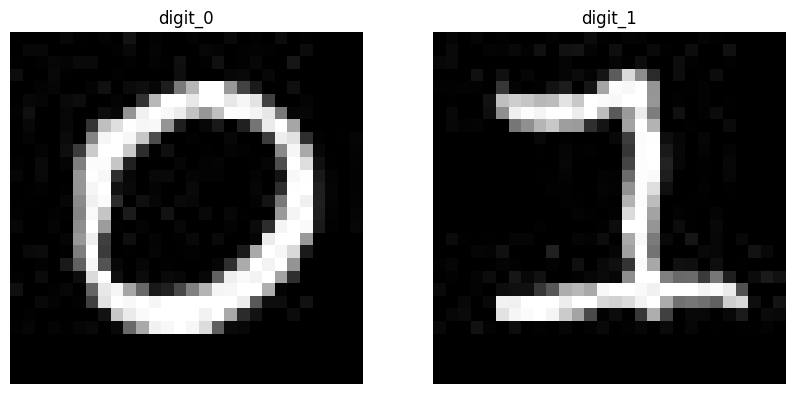

In [4]:
digit_0 = cv2.imread("mnist_0.jpg")
digit_1 = cv2.imread("mnist_1.jpg")

digit_0_gray = cv2.imread("mnist_0.jpg")
digit_1_gray = cv2.imread("mnist_1.jpg")

#visualize image
fix, axs = plt.subplots(1,2, figsize=(10,5))
axs[0].imshow(digit_0_gray, cmap="gray", interpolation = 'none')
axs[0].set_title("digit_0")
axs[0].axis("off")
axs[1].imshow(digit_1_gray, cmap="gray", interpolation = 'none')
axs[1].set_title("digit_1")
axs[1].axis("off")

plt.show()


## 1.1. Convert Numpy array to Torch tnesors

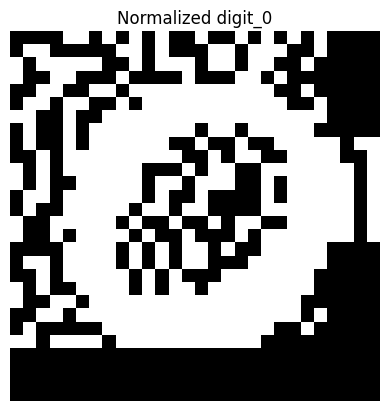

In [5]:
img_tensor_0 = torch.tensor(digit_0_gray, dtype = torch.float32)
img_tensor_1 = torch.tensor(digit_1_gray, dtype = torch.float32)

plt.imshow(img_tensor_0, cmap="gray")
plt.title("Normalized digit_0")
plt.axis("off")
plt.show()

## 1.2 Creating Input batch

* In PyTorch, image tensors typically follow the shape convention `[N, C, H, W]` while Tensorflow follows `[N, H, W, C]``
* In PyTorch, the forward pass of input images to the model is expected to have a batch_size > 1

In [6]:
batch_tensor = torch.stack([img_tensor_0, img_tensor_1])
print(f"Shape of batch tensor: {batch_tensor.shape}")

Shape of batch tensor: torch.Size([2, 28, 28, 3])


* Therefore to bring the color channel to the second dimmension, we use `torch.view()` or `torch.permute()

In [7]:
batch_input = batch_tensor.permute(0,3,1,2)
print(f"Shape of batch tensor: {batch_input.shape}")

Shape of batch tensor: torch.Size([2, 3, 28, 28])


# 2. Introduction to Tensors and its operations

* A scalar tesnor or a 0 dimmensional tensor is given as

In [8]:
scalar = torch.tensor(21)
print(f"Shape of scalar tensor: {scalar.shape}")


Shape of scalar tensor: torch.Size([])


* a 1D tensor is ginven as:

In [9]:
one_dim = torch.tensor([1,2,3,4,5])
print(f"Shape of 1D tensor: {one_dim.shape}")

Shape of 1D tensor: torch.Size([5])


* a 2D tensor is given as:

In [10]:
two_dim = torch.tensor([[1,2,3,4],[12,34,11,45], [5,2,3,5]])
print(f"Shape of 2D tensor: {two_dim.shape}")

Shape of 2D tensor: torch.Size([3, 4])


* A 3D tensor is given as

In [11]:
three_dim = torch.tensor(
    [
        [[1,2],[1,2]],
        [[3,4],[3,4]]
    ]
)

print(f'shpale of 3D tensor: {three_dim.shape}')

shpale of 3D tensor: torch.Size([2, 2, 2])


# 2.1. Construct tensor

* creating 1s and 0s

In [12]:
#1s
a = torch.ones(3, 4)

#0s
b = torch.zeros(4, 3)

print(f"1s tensor: \n {a}")
print(f"0s tensor: \n {b}")

1s tensor: 
 tensor([[1., 1., 1., 1.],
        [1., 1., 1., 1.],
        [1., 1., 1., 1.]])
0s tensor: 
 tensor([[0., 0., 0.],
        [0., 0., 0.],
        [0., 0., 0.],
        [0., 0., 0.]])


## 2.2. Access an element in tensor

In [13]:
# 1D
print(one_dim[0])

#2D
print(two_dim[0, 1])

#3D
print(three_dim[0, 0, 1])

tensor(1)
tensor(2)
tensor(2)


* selecting a row or column

In [14]:
#row
print(two_dim[0, :]," or ", two_dim[0])

#column
print(two_dim[:, 0])

tensor([1, 2, 3, 4])  or  tensor([1, 2, 3, 4])
tensor([ 1, 12,  5])


## 2.3. Specify the data type of the elements
* PyTorch, by default, decides the data yype of the elements of the tensor such that the data type can cover all the elements of the tensor.
* we can overide this like this:

In [15]:
# specifiying the data type to be for integers
int_tensor = torch.tensor([1,2,3,4,5], dtype = torch.int32)
print(int_tensor.dtype)
# specifiying the the data type to be for floating points
float_tensor = torch.tensor([1,2,3,4,5], dtype = torch.float32)
print(float_tensor.dtype)

torch.int32
torch.float32


## 2.4. Tensor to/from Numpy Array

In [16]:
# Numpy array to tensor
x = np.array([2,3,41,5,3,4])
x_tensor = torch.from_numpy(x)
print(f"x_tensor: {x_tensor}")

# tensor to Numpy
three_dim_np = three_dim.numpy()
print(f"three_dim_np: {three_dim_np}")

x_tensor: tensor([ 2,  3, 41,  5,  3,  4])
three_dim_np: [[[1 2]
  [1 2]]

 [[3 4]
  [3 4]]]


## 2.5. Arithmetic Operations on Tensors

In [17]:
# Create tensor
tensor1 = torch.tensor([[1,2,3],[4,5,6]])
tensor2 = torch.tensor([[-1,2,-3],[4,-5,6]])

### 2.5.1. Addition

In [18]:
print(tensor1 + tensor2)
# we can also do
print(torch.add(tensor1, tensor2))

tensor([[ 0,  4,  0],
        [ 8,  0, 12]])
tensor([[ 0,  4,  0],
        [ 8,  0, 12]])


### 2.5.2. Substraction

In [19]:
print(tensor1 - tensor2)
# we can also do
print(torch.sub(tensor1, tensor2))

tensor([[ 2,  0,  6],
        [ 0, 10,  0]])
tensor([[ 2,  0,  6],
        [ 0, 10,  0]])


### 2.5.3. Multiplication
* Element wise operation:

In [20]:
print(tensor1 * tensor2)

tensor([[ -1,   4,  -9],
        [ 16, -25,  36]])


* For matrix multiplication, we need to make sure the number of columns of the first matrix need to match the number of the rows of the second matrix

In [21]:
# we need to create a new matrix that workes with tensor1
tensor3 = torch.tensor([[1,2],[3,4],[5,6]])
print(torch.matmul(tensor1, tensor3))
# or can say
print(tensor1 @ tensor3)
# or can say
print(torch.mm(tensor1, tensor3))

tensor([[22, 28],
        [49, 64]])
tensor([[22, 28],
        [49, 64]])
tensor([[22, 28],
        [49, 64]])


## 2.6. Broadcasting
* used to add to mismatching tensors

In [22]:
scalar_tensor = torch.tensor(2)
print(one_dim," changes to by adding",scalar_tensor, "to",one_dim + scalar_tensor)


tensor([1, 2, 3, 4, 5])  changes to by adding tensor(2) to tensor([3, 4, 5, 6, 7])


In [23]:
# mismatching tensors
x_tensor = torch.tensor([[1,2,3]])
y_tensor = torch.tensor([[1],[2],[3]])
print(x_tensor,"and",y_tensor)
print(x_tensor + y_tensor)

tensor([[1, 2, 3]]) and tensor([[1],
        [2],
        [3]])
tensor([[2, 3, 4],
        [3, 4, 5],
        [4, 5, 6]])


## 2.7. CPU vs GPU Tensor
* creating a tensor for GPU

In [24]:
tensor_gpu = torch.tensor([[1,2,3],[2,3,1],[3,1,2]], device='cuda')

* creating a tensor for cpu

In [26]:
tensor_cpu = torch.tensor([[2,3,1],[3,2,1],[1,2,3]], device='cpu')

* we can move the GPU tensor to CPU and vice versa

In [27]:
tensor_gpu_cpu = tensor_gpu.to(device='cpu')
tensor_cpu_gpu = tensor_cpu.to(device='cuda')